In [1]:

# imports
import os
import sys
import types
import json
import base64

# figure size/format
fig_width = 7
fig_height = 5
fig_format = 'retina'
fig_dpi = 96
interactivity = ''
is_shiny = False
is_dashboard = False
plotly_connected = True

# matplotlib defaults / format
try:
  import matplotlib.pyplot as plt
  plt.rcParams['figure.figsize'] = (fig_width, fig_height)
  plt.rcParams['figure.dpi'] = fig_dpi
  plt.rcParams['savefig.dpi'] = "figure"

  # IPython 7.14 deprecated set_matplotlib_formats from IPython
  try:
    from matplotlib_inline.backend_inline import set_matplotlib_formats
  except ImportError:
    # Fall back to deprecated location for older IPython versions
    from IPython.display import set_matplotlib_formats
    
  set_matplotlib_formats(fig_format)
except Exception:
  pass

# plotly use connected mode
try:
  import plotly.io as pio
  if plotly_connected:
    pio.renderers.default = "notebook_connected"
  else:
    pio.renderers.default = "notebook"
  for template in pio.templates.keys():
    pio.templates[template].layout.margin = dict(t=30,r=0,b=0,l=0)
except Exception:
  pass

# disable itables paging for dashboards
if is_dashboard:
  try:
    from itables import options
    options.dom = 'fiBrtlp'
    options.maxBytes = 1024 * 1024
    options.language = dict(info = "Showing _TOTAL_ entries")
    options.classes = "display nowrap compact"
    options.paging = False
    options.searching = True
    options.ordering = True
    options.info = True
    options.lengthChange = False
    options.autoWidth = False
    options.responsive = True
    options.keys = True
    options.buttons = []
  except Exception:
    pass
  
  try:
    import altair as alt
    # By default, dashboards will have container sized
    # vega visualizations which allows them to flow reasonably
    theme_sentinel = '_quarto-dashboard-internal'
    def make_theme(name):
        nonTheme = alt.themes._plugins[name]    
        def patch_theme(*args, **kwargs):
            existingTheme = nonTheme()
            if 'height' not in existingTheme:
              existingTheme['height'] = 'container'
            if 'width' not in existingTheme:
              existingTheme['width'] = 'container'

            if 'config' not in existingTheme:
              existingTheme['config'] = dict()
            
            # Configure the default font sizes
            title_font_size = 15
            header_font_size = 13
            axis_font_size = 12
            legend_font_size = 12
            mark_font_size = 12
            tooltip = False

            config = existingTheme['config']

            # The Axis
            if 'axis' not in config:
              config['axis'] = dict()
            axis = config['axis']
            if 'labelFontSize' not in axis:
              axis['labelFontSize'] = axis_font_size
            if 'titleFontSize' not in axis:
              axis['titleFontSize'] = axis_font_size  

            # The legend
            if 'legend' not in config:
              config['legend'] = dict()
            legend = config['legend']
            if 'labelFontSize' not in legend:
              legend['labelFontSize'] = legend_font_size
            if 'titleFontSize' not in legend:
              legend['titleFontSize'] = legend_font_size  

            # The header
            if 'header' not in config:
              config['header'] = dict()
            header = config['header']
            if 'labelFontSize' not in header:
              header['labelFontSize'] = header_font_size
            if 'titleFontSize' not in header:
              header['titleFontSize'] = header_font_size    

            # Title
            if 'title' not in config:
              config['title'] = dict()
            title = config['title']
            if 'fontSize' not in title:
              title['fontSize'] = title_font_size

            # Marks
            if 'mark' not in config:
              config['mark'] = dict()
            mark = config['mark']
            if 'fontSize' not in mark:
              mark['fontSize'] = mark_font_size

            # Mark tooltips
            if tooltip and 'tooltip' not in mark:
              mark['tooltip'] = dict(content="encoding")

            return existingTheme
            
        return patch_theme

    # We can only do this once per session
    if theme_sentinel not in alt.themes.names():
      for name in alt.themes.names():
        alt.themes.register(name, make_theme(name))
      
      # register a sentinel theme so we only do this once
      alt.themes.register(theme_sentinel, make_theme('default'))
      alt.themes.enable('default')

  except Exception:
    pass

# enable pandas latex repr when targeting pdfs
try:
  import pandas as pd
  if fig_format == 'pdf':
    pd.set_option('display.latex.repr', True)
except Exception:
  pass

# interactivity
if interactivity:
  from IPython.core.interactiveshell import InteractiveShell
  InteractiveShell.ast_node_interactivity = interactivity

# NOTE: the kernel_deps code is repeated in the cleanup.py file
# (we can't easily share this code b/c of the way it is run).
# If you edit this code also edit the same code in cleanup.py!

# output kernel dependencies
kernel_deps = dict()
for module in list(sys.modules.values()):
  # Some modules play games with sys.modules (e.g. email/__init__.py
  # in the standard library), and occasionally this can cause strange
  # failures in getattr.  Just ignore anything that's not an ordinary
  # module.
  if not isinstance(module, types.ModuleType):
    continue
  path = getattr(module, "__file__", None)
  if not path:
    continue
  if path.endswith(".pyc") or path.endswith(".pyo"):
    path = path[:-1]
  if not os.path.exists(path):
    continue
  kernel_deps[path] = os.stat(path).st_mtime
print(json.dumps(kernel_deps))

# set run_path if requested
run_path = 'QzpcVXNlcnNcaHBcRGVza3RvcFxwdWJfcG9ydFxweS1xdWFydG9cQWRleWV5ZS1Kb3NlcGgtU2V5aXNvblxibG9nXEFpckJuQi1BbmFseXNpcw=='
if run_path:
  # hex-decode the path
  run_path = base64.b64decode(run_path.encode("utf-8")).decode("utf-8")
  os.chdir(run_path)

# reset state
%reset

# shiny
# Checking for shiny by using False directly because we're after the %reset. We don't want
# to set a variable that stays in global scope.
if False:
  try:
    import htmltools as _htmltools
    import ast as _ast

    _htmltools.html_dependency_render_mode = "json"

    # This decorator will be added to all function definitions
    def _display_if_has_repr_html(x):
      try:
        # IPython 7.14 preferred import
        from IPython.display import display, HTML
      except:
        from IPython.core.display import display, HTML

      if hasattr(x, '_repr_html_'):
        display(HTML(x._repr_html_()))
      return x

    # ideally we would undo the call to ast_transformers.append
    # at the end of this block whenver an error occurs, we do 
    # this for now as it will only be a problem if the user 
    # switches from shiny to not-shiny mode (and even then likely
    # won't matter)
    import builtins
    builtins._display_if_has_repr_html = _display_if_has_repr_html

    class _FunctionDefReprHtml(_ast.NodeTransformer):
      def visit_FunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

      def visit_AsyncFunctionDef(self, node):
        node.decorator_list.insert(
          0,
          _ast.Name(id="_display_if_has_repr_html", ctx=_ast.Load())
        )
        return node

    ip = get_ipython()
    ip.ast_transformers.append(_FunctionDefReprHtml())

  except:
    pass

def ojs_define(**kwargs):
  import json
  try:
    # IPython 7.14 preferred import
    from IPython.display import display, HTML
  except:
    from IPython.core.display import display, HTML

  # do some minor magic for convenience when handling pandas
  # dataframes
  def convert(v):
    try:
      import pandas as pd
    except ModuleNotFoundError: # don't do the magic when pandas is not available
      return v
    if type(v) == pd.Series:
      v = pd.DataFrame(v)
    if type(v) == pd.DataFrame:
      j = json.loads(v.T.to_json(orient='split'))
      return dict((k,v) for (k,v) in zip(j["index"], j["data"]))
    else:
      return v

  v = dict(contents=list(dict(name=key, value=convert(value)) for (key, value) in kwargs.items()))
  display(HTML('<script type="ojs-define">' + json.dumps(v) + '</script>'), metadata=dict(ojs_define = True))
globals()["ojs_define"] = ojs_define
globals()["__spec__"] = None

{"C:\\Users\\hp\\anaconda3\\Lib\\importlib\\_bootstrap.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\importlib\\_bootstrap_external.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\zipimport.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\codecs.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\aliases.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\__init__.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\utf_8.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\encodings\\cp1252.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\abc.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\io.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\stat.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\_collections_abc.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\genericpath.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\ntpath.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\os.py": 1764950793.0, "C:\\Users\\hp\\anaconda3\\Lib\\_sitebu

In [2]:
# fisrtly we import the needed modules/libraries:

import pandas as pd 
import numpy as np 
from pandas import read_csv
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import plotly.express as px

In [3]:
# Read in the data set:

listing = pd.read_csv("C:\\Users\\hp\\Desktop\\python\\projects\\Listings.csv", 
                low_memory = False, 
                encoding = "ISO-8859-1")

listing.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [4]:
# Taking an overview of data 

listing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   listing_id                   279712 non-null  int64  
 1   name                         279537 non-null  object 
 2   host_id                      279712 non-null  int64  
 3   host_since                   279547 non-null  object 
 4   host_location                278872 non-null  object 
 5   host_response_time           150930 non-null  object 
 6   host_response_rate           150930 non-null  float64
 7   host_acceptance_rate         166625 non-null  float64
 8   host_is_superhost            279547 non-null  object 
 9   host_total_listings_count    279547 non-null  float64
 10  host_has_profile_pic         279547 non-null  object 
 11  host_identity_verified       279547 non-null  object 
 12  neighbourhood                279712 non-null  object 
 13 

In [5]:
#   retaining our original dataframe, by creating a copy:
df = listing.copy()
df.head()

,listing_id,name,host_id,host_since,host_location,host_response_time,host_response_rate,host_acceptance_rate,host_is_superhost,host_total_listings_count,...,minimum_nights,maximum_nights,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable
0,281420,"Beautiful Flat in le Village Montmartre, Paris",1466919,2011-12-03,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
1,3705183,39 mÃÂ² Paris (Sacre CÃ âur),10328771,2013-11-29,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
2,4082273,"Lovely apartment with Terrace, 60m2",19252768,2014-07-31,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
3,4797344,Cosy studio (close to Eiffel tower),10668311,2013-12-17,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f
4,4823489,Close to Eiffel Tower - Beautiful flat : 2 rooms,24837558,2014-12-14,"Paris, Ile-de-France, France",NaN,NaN,NaN,f,1.0,...,2,1125,100.0,10.0,10.0,10.0,10.0,10.0,10.0,f


In [6]:
# preview all col names

print(df.columns.tolist())

['listing_id', 'name', 'host_id', 'host_since', 'host_location', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_total_listings_count', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'district', 'city', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bedrooms', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value', 'instant_bookable']


In [7]:
# format date col correctly:
df["host_since"] = pd.to_datetime(df["host_since"])
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 279712 entries, 0 to 279711
Data columns (total 33 columns):
 #   Column                       Non-Null Count   Dtype         
---  ------                       --------------   -----         
 0   listing_id                   279712 non-null  int64         
 1   name                         279537 non-null  object        
 2   host_id                      279712 non-null  int64         
 3   host_since                   279547 non-null  datetime64[ns]
 4   host_location                278872 non-null  object        
 5   host_response_time           150930 non-null  object        
 6   host_response_rate           150930 non-null  float64       
 7   host_acceptance_rate         166625 non-null  float64       
 8   host_is_superhost            279547 non-null  object        
 9   host_total_listings_count    279547 non-null  float64       
 10  host_has_profile_pic         279547 non-null  object        
 11  host_identity_verified    

In [8]:
# filtering for only Paris location

paris_listing = (
    df
    .query(" city == 'Paris' ")
    .loc[:, ["host_since", "city", "neighbourhood", "accommodates", "price"]] 
)   

paris_listing.info()

<class 'pandas.core.frame.DataFrame'>
Index: 64690 entries, 0 to 279711
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   host_since     64657 non-null  datetime64[ns]
 1   city           64690 non-null  object        
 2   neighbourhood  64690 non-null  object        
 3   accommodates   64690 non-null  int64         
 4   price          64690 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 3.0+ MB


In [9]:
# checking for NAs values :

paris_listing.isna().sum()

host_since       33
city              0
neighbourhood     0
accommodates      0
price             0
dtype: int64

In [10]:
# Get an overview of our basic stats:
paris_listing.describe()

,host_since,accommodates,price
count,64657,64690.000000,64690.000000
mean,2015-11-01 11:06:05.528867584,3.037997,113.096445
min,2008-08-30 00:00:00,0.000000,0.000000
25%,2014-03-09 00:00:00,2.000000,59.000000
50%,2015-07-07 00:00:00,2.000000,80.000000
75%,2017-05-29 00:00:00,4.000000,120.000000
max,2021-02-07 00:00:00,16.000000,12000.000000
std,NaN,1.588766,214.433668


In [11]:
# inspecting cols where accommodates =0 as well as price
paris_listing.query(" accommodates == 0 and price == 0 ").count()

host_since       54
city             54
neighbourhood    54
accommodates     54
price            54
dtype: int64

In [12]:
paris_listing_neighbourhood = (
    paris_listing
    .groupby("neighbourhood")
    .agg(avg_price=("price", "mean"))
    .sort_values(by="avg_price", ascending=False)
    .reset_index()
)

paris_listing_neighbourhood.head() 

,neighbourhood,avg_price
0,Elysee,210.536765
1,Louvre,175.379972
2,Passy,161.144635
3,Palais-Bourbon,156.856578
4,Luxembourg,155.638639


In [13]:
# filtering for accommodation in the most expensive parts of Paris:

paris_listing_accommodates = (
   paris_listing
   .query(" neighbourhood == 'Elysee' ")
   .groupby(["accommodates"], as_index=True)
   .agg({"price": "mean"})
   .sort_values(by="price")
)
 
paris_listing_accommodates.head()

,price
accommodates,
0,0.000000
1,79.522222
3,152.828767
2,155.103352
4,212.096070


In [14]:
# creating a table for time series object
import warnings 
warnings.filterwarnings("ignore")

paris_listing_over_time = (
        paris_listing
        .set_index("host_since")
        .resample("YE")
        .agg({ "price": "mean", "neighbourhood":"count"})
    
)


paris_listing_over_time

,price,neighbourhood
host_since,,
2008-12-31,77.750000,4
2009-12-31,159.641509,106
2010-12-31,125.031250,416
2011-12-31,124.828230,1339
2012-12-31,111.578615,4592
2013-12-31,107.096414,8142
2014-12-31,100.253800,10922
2015-12-31,103.646250,12147
2016-12-31,114.159847,8871


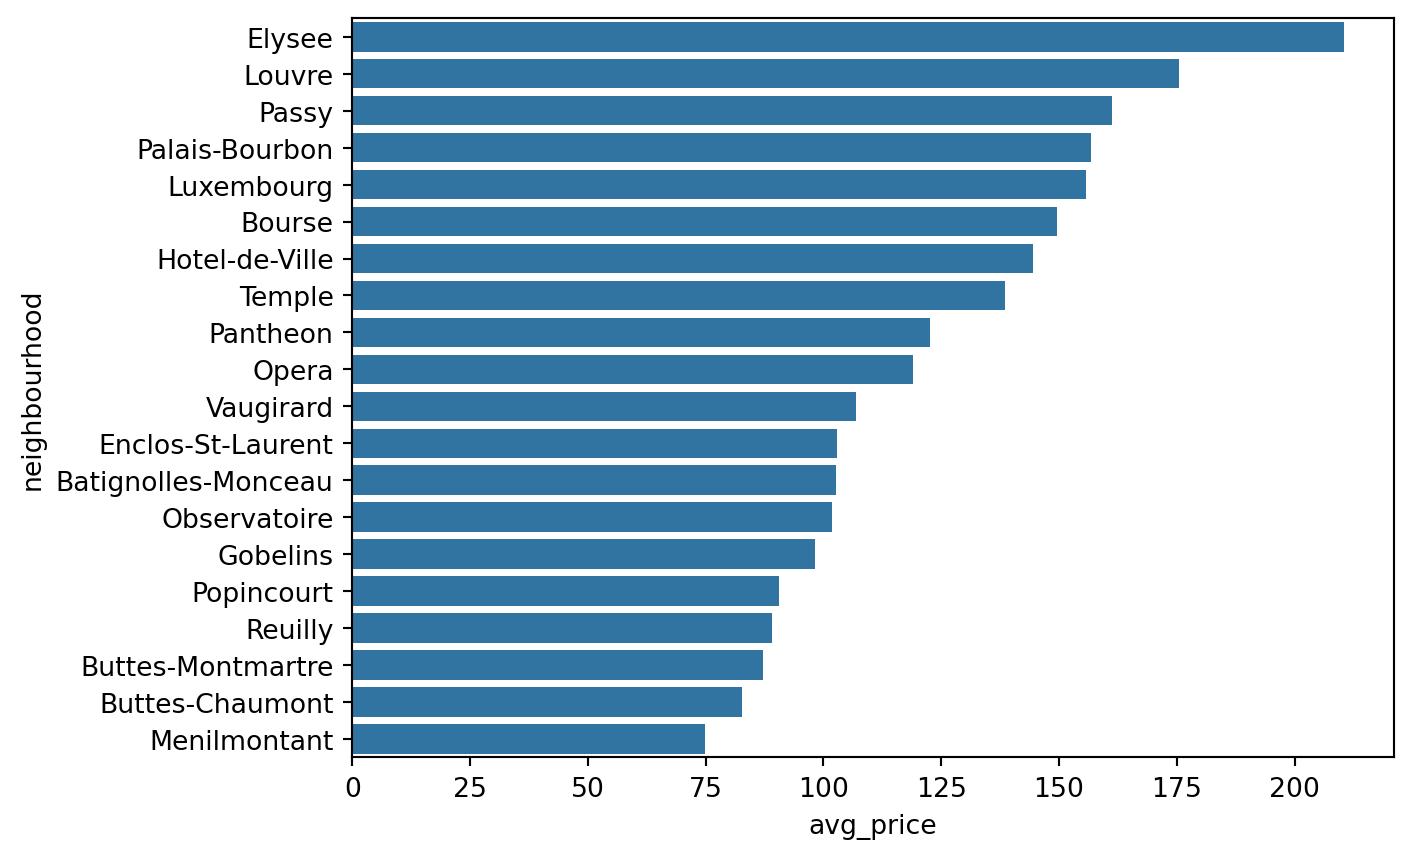

In [15]:
# visualizing via a barplot:
sns.barplot(paris_listing_neighbourhood, 
            x = "avg_price",
            y= "neighbourhood")

plt.show()

In [16]:
# visualizing via the plotly api:

fig = px.bar(
    paris_listing_neighbourhood,
    x="avg_price",
    y="neighbourhood",
    orientation="h",
    title="Average Price Listing by Paris Neighbourhood", 
    labels={"avg_price": "Average Price(Euros)", 
             "neighbourhood":"Paris Neighbourhood"}
)


fig.update_yaxes(
    categoryorder='array',
    categoryarray=paris_listing_neighbourhood['neighbourhood']
)

fig.update_yaxes(autorange="reversed")


fig.show()

In [17]:
# visualizing average price of Paris listing accommodation:

fig = px.bar(
    paris_listing_accommodates,
    orientation="v",
    title="Average Price Listing by Paris Neighbourhood"
)

fig.update_layout(
    xaxis_title="Accommodation Capacity",
    yaxis_title="Price (Euros)")

fig.update_layout(showlegend=False)

fig.show()

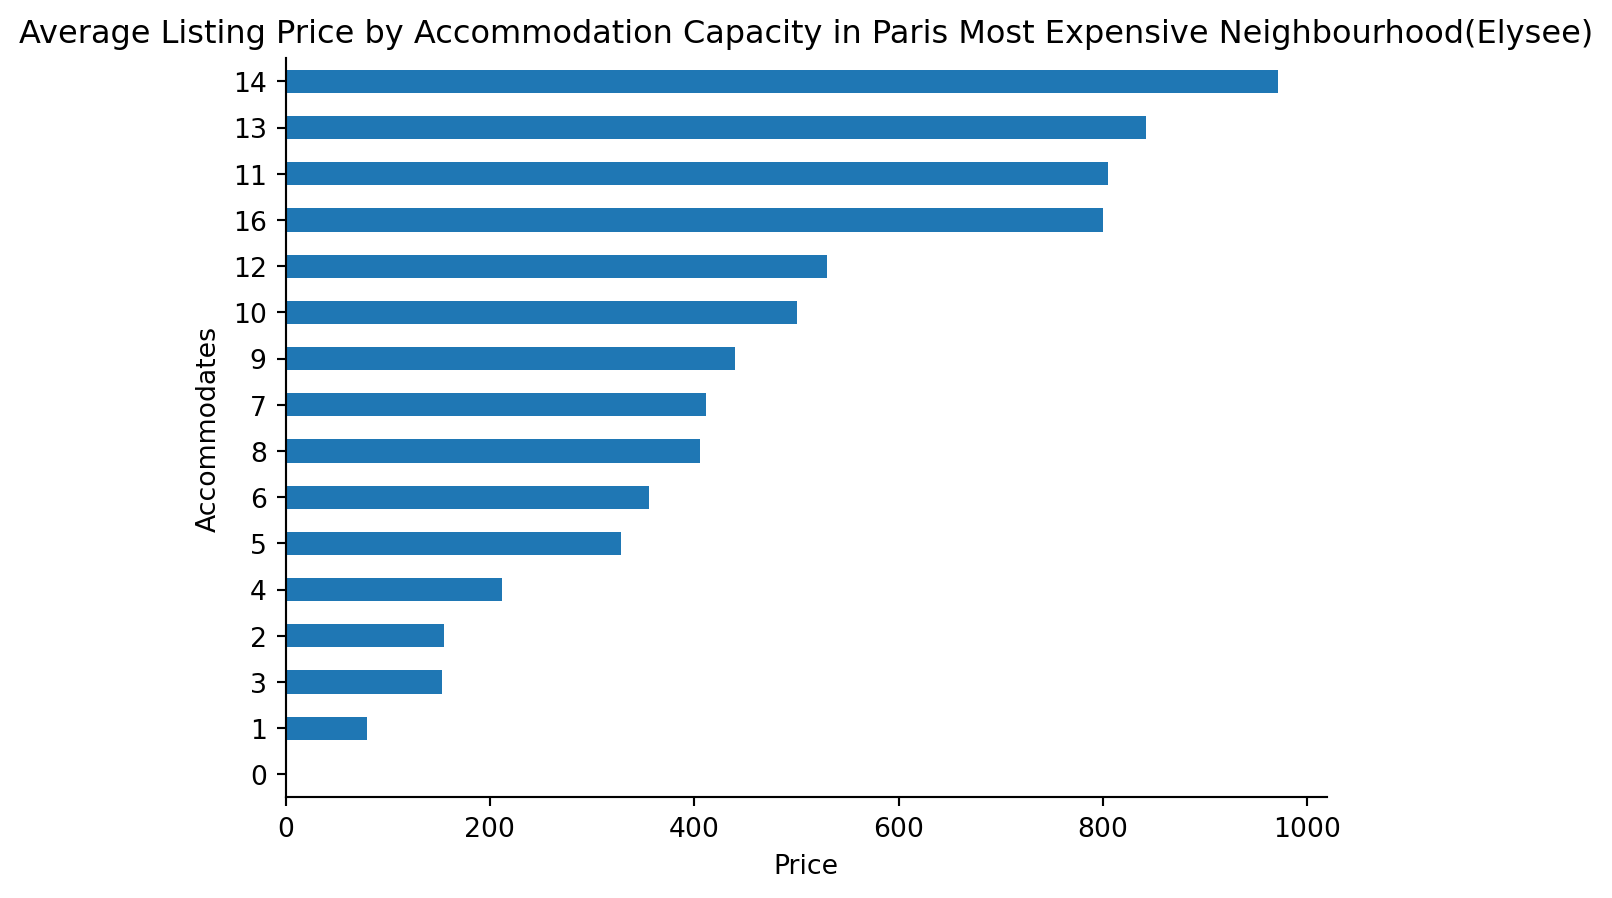

In [18]:
# visualizing via the pandas API : the price vs accommodation capacity in Paris
(paris_listing_accommodates.plot.barh( 
            xlabel= "Price",
            ylabel= "Accommodates",
            title="Average Listing Price by Accommodation Capacity in Paris Most Expensive Neighbourhood(Elysee)",
            legend=None)

)

sns.despine()

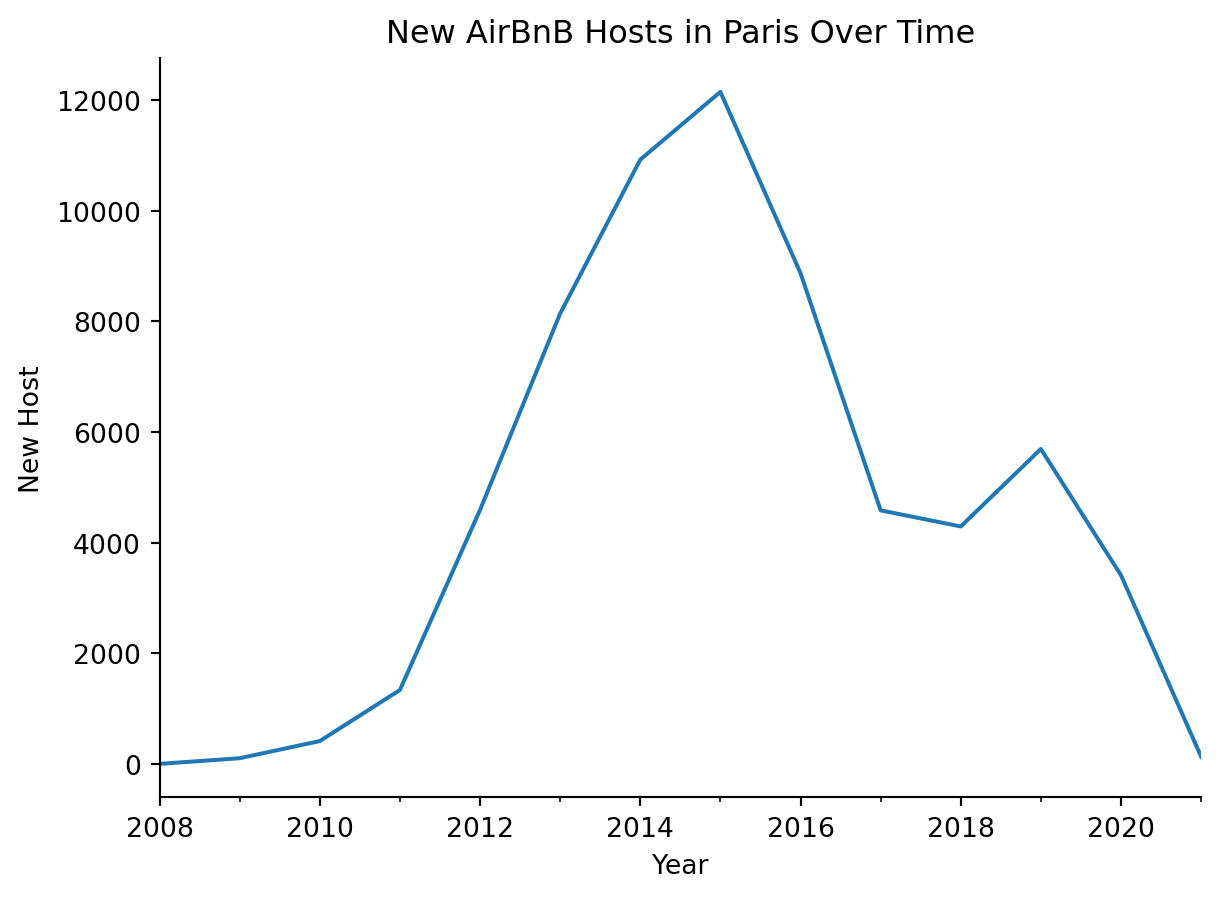

In [19]:
# Creating dual axis plot : firstly we need paris listing over time plot

paris_listing_over_time["neighbourhood"].plot(
    ylabel="New Host",
    xlabel="Year",
    title="New AirBnB Hosts in Paris Over Time"
    
)

sns.despine()

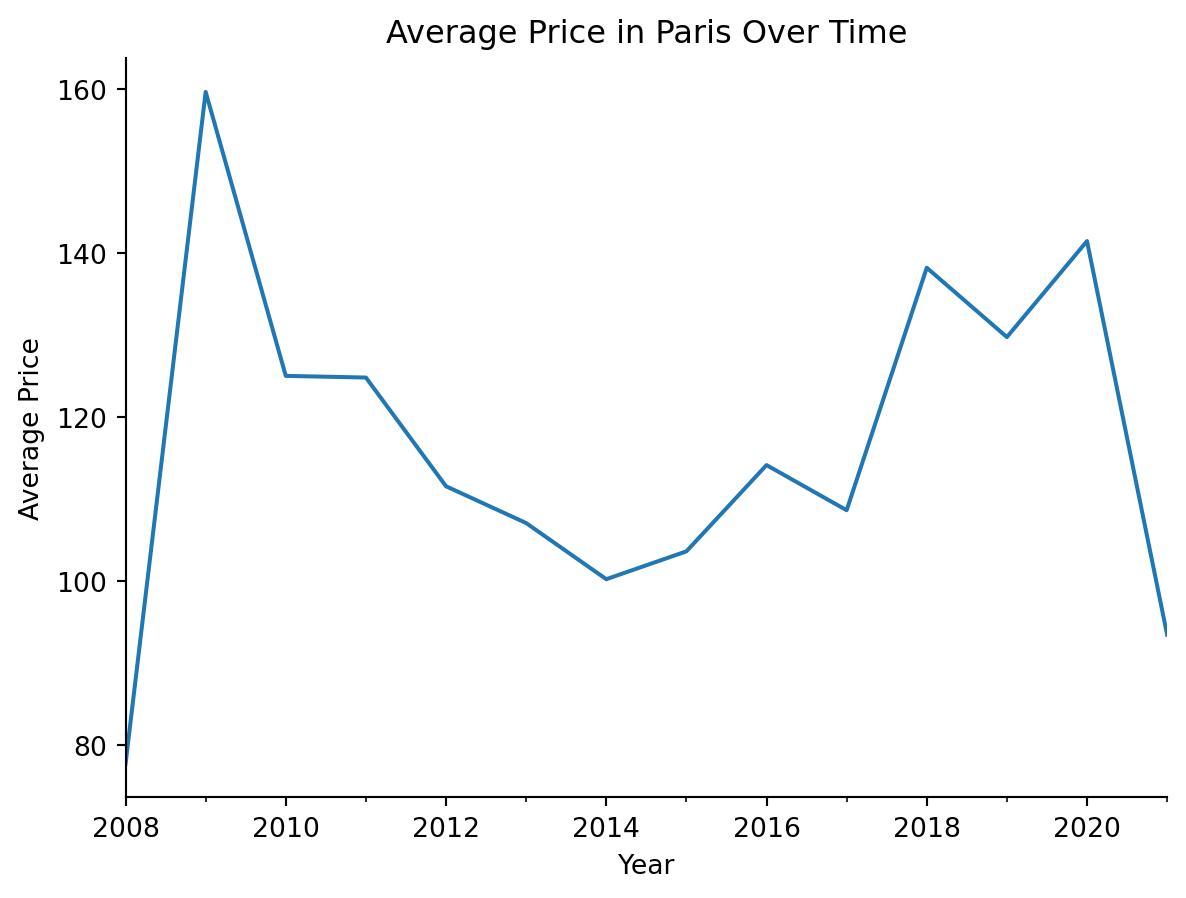

In [20]:
# secondly we need paris listing over time by average price plot
paris_listing_over_time["price"].plot(
    ylabel="Average Price",
    xlabel="Year",
    title="Average Price in Paris Over Time"
    
)

sns.despine()

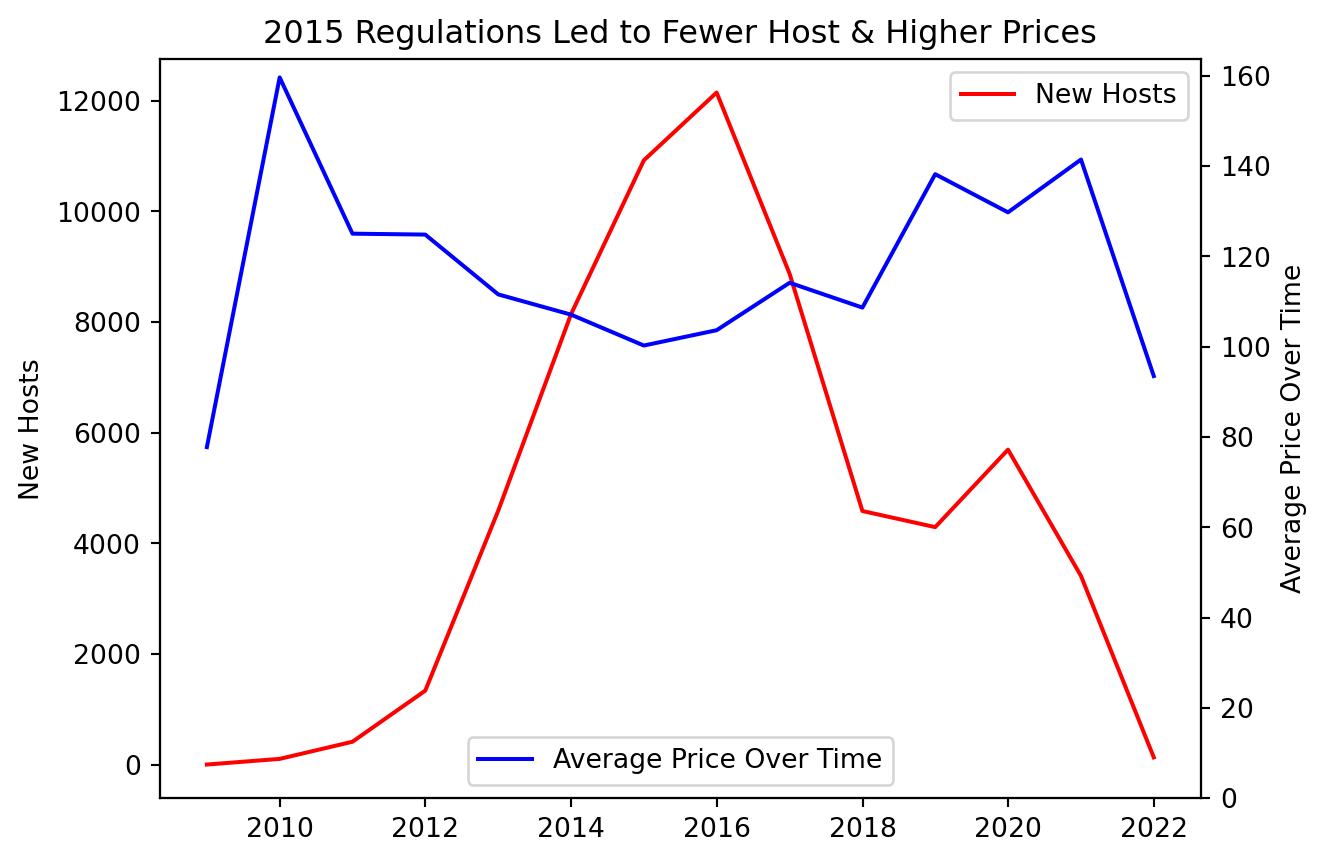

In [21]:
# combining both plots together via the twinx() method from matplolib:
fig,  ax = plt.subplots()

ax.plot(paris_listing_over_time.index, 
     paris_listing_over_time["neighbourhood"], 
     label = "New Hosts", 
     c ="red"
)

ax.set_ylabel("New Hosts")
plt.legend(loc="upper right")


ax2 = ax.twinx()

ax2.plot(paris_listing_over_time.index, 
    paris_listing_over_time["price"], 
    label = "Average Price Over Time", 
    c ="blue"
)

ax2.set_ylim(0)

ax2.set_ylabel("Average Price Over Time")
ax.set_title("2015 Regulations Led to Fewer Host & Higher Prices")
plt.legend(loc="lower center")